# Planar Geometry Using Shapely

In [1]:
import ezdxf
import ezdxf_shapely
import shapely.geometry as sg
import shapely
import plotly.express as px
import plotly.graph_objects as po
import numpy as np
import math
from ipywidgets import interact

In [2]:
dxf_doc = ezdxf.readfile("constricted_swedish_oval.dxf")

In [3]:
dxf_entities = list(dxf_doc.modelspace().query('* [layer=="0"]'))
dxf_entities

[<class 'ezdxf.entities.line.Line'> LINE(#62),
 <class 'ezdxf.entities.line.Line'> LINE(#63),
 <class 'ezdxf.entities.line.Line'> LINE(#64),
 <class 'ezdxf.entities.line.Line'> LINE(#65),
 <class 'ezdxf.entities.line.Line'> LINE(#66),
 <class 'ezdxf.entities.line.Line'> LINE(#67),
 <class 'ezdxf.entities.line.Line'> LINE(#68),
 <class 'ezdxf.entities.line.Line'> LINE(#69),
 <class 'ezdxf.entities.arc.Arc'> ARC(#6A),
 <class 'ezdxf.entities.arc.Arc'> ARC(#6B),
 <class 'ezdxf.entities.arc.Arc'> ARC(#6C),
 <class 'ezdxf.entities.arc.Arc'> ARC(#6D),
 <class 'ezdxf.entities.arc.Arc'> ARC(#73),
 <class 'ezdxf.entities.arc.Arc'> ARC(#74),
 <class 'ezdxf.entities.arc.Arc'> ARC(#75),
 <class 'ezdxf.entities.arc.Arc'> ARC(#76),
 <class 'ezdxf.entities.line.Line'> LINE(#77),
 <class 'ezdxf.entities.line.Line'> LINE(#78),
 <class 'ezdxf.entities.line.Line'> LINE(#79),
 <class 'ezdxf.entities.line.Line'> LINE(#7A),
 <class 'ezdxf.entities.arc.Arc'> ARC(#7B),
 <class 'ezdxf.entities.arc.Arc'> ARC(#7

In [4]:
groove_contours = ezdxf_shapely.convert_all(dxf_entities)

In [17]:
def add_line_string(fig, geom):
    xy = np.asarray(geom.xy)
    fig.add_scatter(x=xy[0], y=xy[1])

def add_polygon(fig, geom):
    xy = np.asarray(geom.exterior.xy)
    fig.add_scatter(x=xy[0], y=xy[1], fill="toself")

def plot_geom(geom, fig=None) -> po.Figure:       
    if fig is None:    
        fig=po.Figure()
        
    match geom:
        case sg.LineString():
            add_line_string(fig, geom)
        case sg.Polygon():
            add_polygon(fig, geom)
        case sg.MultiLineString() | sg.MultiPolygon:
            for g in geom.geoms:
                plot_geom(g, fig)
                
    fig.update_yaxes(
        scaleanchor="x",
        scaleratio=1,
    )
    return fig

def plot_geoms(geoms) -> po.Figure:
    fig = po.Figure()
    for g in geoms:
        plot_geom(g, fig)
    return fig

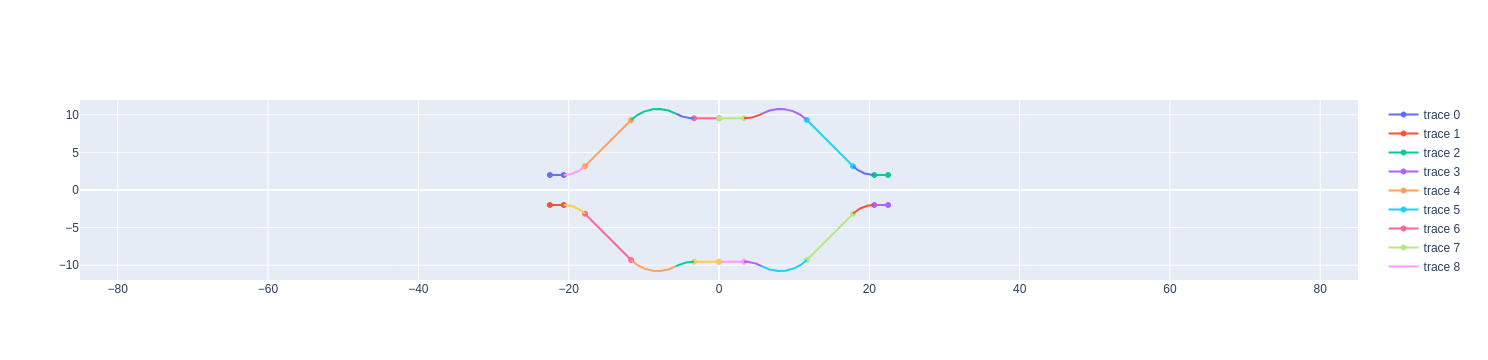

In [18]:
plot_geoms(groove_contours)

In [19]:
#groove_contours.sort(key=lambda g: g.bounds[0])
groove_contours

[<LINESTRING (-22.5 2, -20.657 2)>,
 <LINESTRING (-22.5 -2, -20.657 -2)>,
 <LINESTRING (20.657 2, 22.5 2)>,
 <LINESTRING (20.657 -2, 22.5 -2)>,
 <LINESTRING (-17.828 3.172, -11.687 9.313)>,
 <LINESTRING (17.828 3.172, 11.687 9.313)>,
 <LINESTRING (-17.828 -3.172, -11.687 -9.313)>,
 <LINESTRING (17.828 -3.172, 11.687 -9.313)>,
 <LINESTRING (-20.657 2, -20.585 2.001, -20.514 2.003, -20.443 2.006, -20.371...>,
 <LINESTRING (-17.828 -3.172, -17.879 -3.122, -17.931 -3.072, -17.984 -3.024,...>,
 <LINESTRING (17.828 3.172, 17.879 3.122, 17.931 3.072, 17.984 3.024, 18.037 ...>,
 <LINESTRING (20.657 -2, 20.585 -2.001, 20.514 -2.003, 20.443 -2.006, 20.371 ...>,
 <LINESTRING (-5.742 10.158, -5.821 10.2, -5.9 10.241, -5.98 10.281, -6.061 1...>,
 <LINESTRING (11.687 9.313, 11.624 9.375, 11.559 9.437, 11.493 9.497, 11.426 ...>,
 <LINESTRING (-11.687 -9.313, -11.624 -9.375, -11.559 -9.437, -11.493 -9.497,...>,
 <LINESTRING (5.742 -10.158, 5.821 -10.2, 5.9 -10.241, 5.98 -10.281, 6.061 -1...>,
 <LINEST

In [20]:
upper_contours = list(filter(lambda g: g.bounds[1] > 0, groove_contours))
upper_contours = ezdxf_shapely.coerce_line_ends(upper_contours)
upper_contours

[<LINESTRING (-22.5 2, -20.657 2)>,
 <LINESTRING (20.657 2, 22.5 2)>,
 <LINESTRING (-17.828 3.172, -11.687 9.313)>,
 <LINESTRING (17.828 3.172, 11.687 9.313)>,
 <LINESTRING (-20.657 2, -20.585 2.001, -20.514 2.003, -20.443 2.006, -20.371...>,
 <LINESTRING (17.828 3.172, 17.879 3.122, 17.931 3.072, 17.984 3.024, 18.037 ...>,
 <LINESTRING (-5.742 10.158, -5.821 10.2, -5.9 10.241, -5.98 10.281, -6.061 1...>,
 <LINESTRING (11.687 9.313, 11.624 9.375, 11.559 9.437, 11.493 9.497, 11.426 ...>,
 <LINESTRING (-3.332 9.539, 0 9.539)>,
 <LINESTRING (3.332 9.539, 0 9.539)>,
 <LINESTRING (-5.742 10.158, -5.66 10.114, -5.577 10.071, -5.493 10.03, -5.40...>,
 <LINESTRING (3.332 9.539, 3.425 9.54, 3.518 9.542, 3.611 9.547, 3.704 9.553,...>]

In [21]:
lower_contours = list(filter(lambda g: g.bounds[1] < 0, groove_contours))
lower_contours = ezdxf_shapely.coerce_line_ends(lower_contours)
lower_contours

[<LINESTRING (-22.5 -2, -20.657 -2)>,
 <LINESTRING (20.657 -2, 22.5 -2)>,
 <LINESTRING (-17.828 -3.172, -11.687 -9.313)>,
 <LINESTRING (17.828 -3.172, 11.687 -9.313)>,
 <LINESTRING (-17.828 -3.172, -17.879 -3.122, -17.931 -3.072, -17.984 -3.024,...>,
 <LINESTRING (20.657 -2, 20.585 -2.001, 20.514 -2.003, 20.443 -2.006, 20.371 ...>,
 <LINESTRING (-11.687 -9.313, -11.624 -9.375, -11.559 -9.437, -11.493 -9.497,...>,
 <LINESTRING (5.742 -10.158, 5.821 -10.2, 5.9 -10.241, 5.98 -10.281, 6.061 -1...>,
 <LINESTRING (3.332 -9.539, 0 -9.539)>,
 <LINESTRING (-3.332 -9.539, 0 -9.539)>,
 <LINESTRING (-3.332 -9.539, -3.425 -9.54, -3.518 -9.542, -3.611 -9.547, -3.7...>,
 <LINESTRING (5.742 -10.158, 5.66 -10.114, 5.577 -10.071, 5.493 -10.03, 5.409...>]

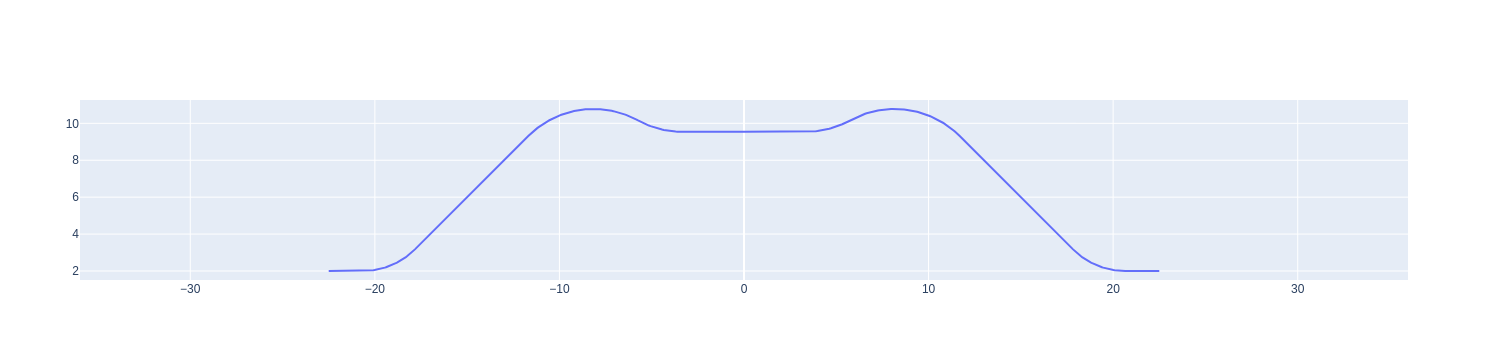

In [22]:
upper_contour = shapely.line_merge(sg.MultiLineString(upper_contours))
plot_geom(upper_contour)

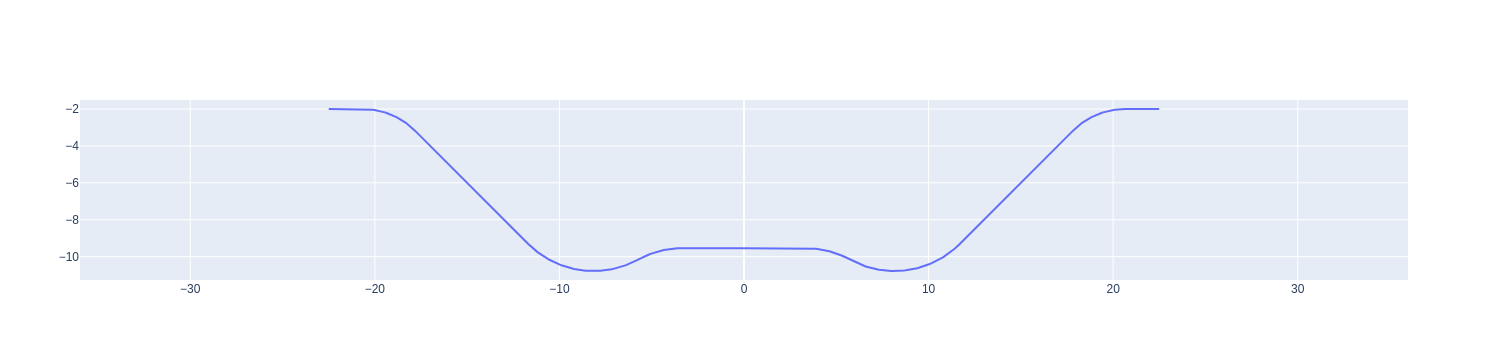

In [23]:
lower_contour = shapely.line_merge(sg.MultiLineString(lower_contours))
plot_geom(lower_contour)

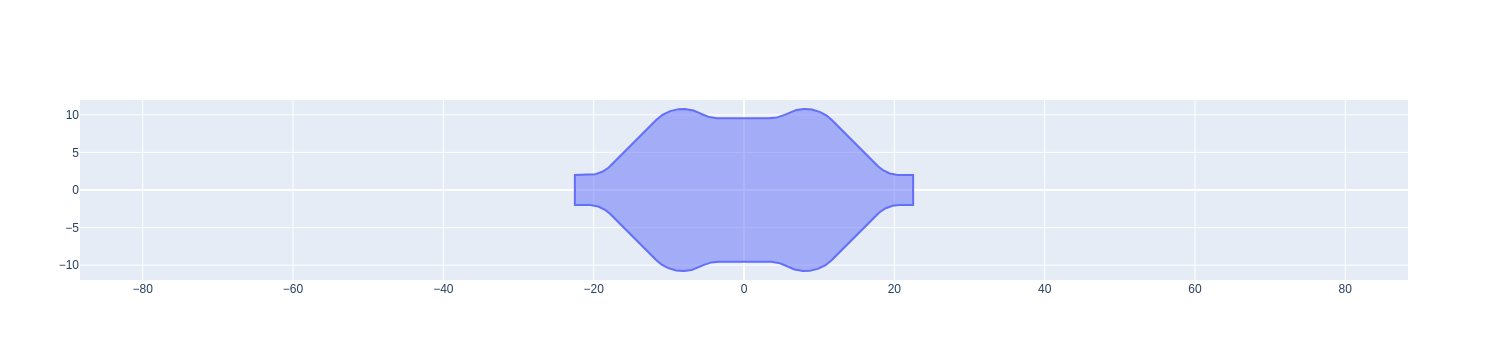

In [24]:
cross_section = shapely.concave_hull(sg.MultiLineString([upper_contour, lower_contour]))
plot_geom(cross_section)

In [50]:
@interact(xmin=(-22.5, 22.5, 0.1), xmax=(-22.5, 22.5, 0.1))
def clip_cross_section(xmin=-10, xmax=10):
    clipped = shapely.clip_by_rect(
        cross_section,
        xmin, -math.inf, xmax, math.inf
    )
    fig = plot_geoms([cross_section, clipped])
    mean_height = clipped.area / (clipped.bounds[2] - clipped.bounds[0])
    fig.add_hline(y=mean_height/2)    
    fig.add_hline(y=-mean_height/2)
    fig.update_layout(title_text=f"area = {clipped.area}, mean_height = {mean_height}")
    return fig

interactive(children=(FloatSlider(value=-10.0, description='xmin', max=22.5, min=-22.5), FloatSlider(value=10.…